In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [4]:
from google.colab import files
uploaded = files.upload()

Saving blinkit_customer_feedback.csv to blinkit_customer_feedback.csv
Saving blinkit_customers.csv to blinkit_customers (1).csv
Saving blinkit_delivery_performance.csv to blinkit_delivery_performance.csv
Saving blinkit_inventory.csv to blinkit_inventory.csv
Saving blinkit_inventoryNew.csv to blinkit_inventoryNew.csv
Saving blinkit_marketing_performance.csv to blinkit_marketing_performance.csv
Saving blinkit_order_items.csv to blinkit_order_items.csv
Saving blinkit_orders.csv to blinkit_orders.csv
Saving blinkit_products - Copy.csv to blinkit_products - Copy.csv
Saving blinkit_products.csv to blinkit_products.csv


In [5]:
import pandas as pd

orders = pd.read_csv('blinkit_orders.csv')
order_items = pd.read_csv('blinkit_order_items.csv')
products = pd.read_csv('blinkit_products.csv')
customers = pd.read_csv('blinkit_customers.csv')
inventory = pd.read_csv('blinkit_inventory.csv')
delivery = pd.read_csv('blinkit_delivery_performance.csv')
marketing = pd.read_csv('blinkit_marketing_performance.csv')
feedback = pd.read_csv('blinkit_customer_feedback.csv')

# quick check
print(orders.shape)
print(orders.head())

(5000, 10)
     order_id  customer_id           order_date promised_delivery_time  \
0  1961864118     30065862  2024-07-17 08:34:01    2024-07-17 08:52:01   
1  1549769649      9573071  2024-05-28 13:14:29    2024-05-28 13:25:29   
2  9185164487     45477575  2024-09-23 13:07:12    2024-09-23 13:25:12   
3  9644738826     88067569  2023-11-24 16:16:56    2023-11-24 16:34:56   
4  5427684290     83298567  2023-11-20 05:00:39    2023-11-20 05:17:39   

  actual_delivery_time delivery_status  order_total payment_method  \
0  2024-07-17 08:47:01         On Time      3197.07           Cash   
1  2024-05-28 13:27:29         On Time       976.55           Cash   
2  2024-09-23 13:29:12         On Time       839.05            UPI   
3  2023-11-24 16:33:56         On Time       440.23           Card   
4  2023-11-20 05:18:39         On Time      2526.68           Cash   

   delivery_partner_id  store_id  
0                63230      4771  
1                14983      7534  
2                3

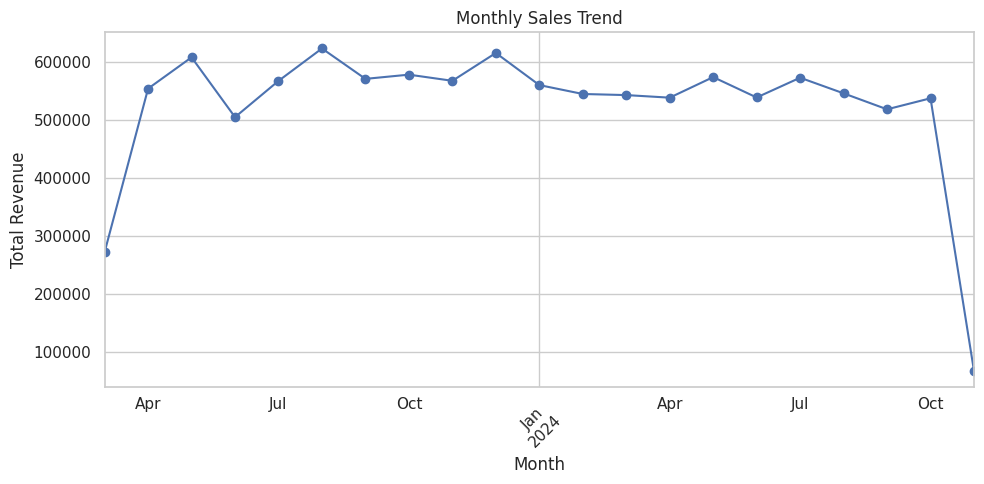

In [6]:
orders['order_date'] = pd.to_datetime(orders['order_date'])
orders['order_month'] = orders['order_date'].dt.to_period('M')

monthly_sales = orders.groupby('order_month')['order_total'].sum()

plt.figure(figsize=(10,5))
monthly_sales.plot(kind='line', marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**In above graph,
Sales increased steadily during the first half of the year and reached a peak around the middle months.
The trend suggests that business performance varies across different months, which can help in planning promotions and inventory**.

/tmp/ipykernel_4815/1967305091.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='payment_method', y='order_total', data=orders, estimator=sum, ci=None)


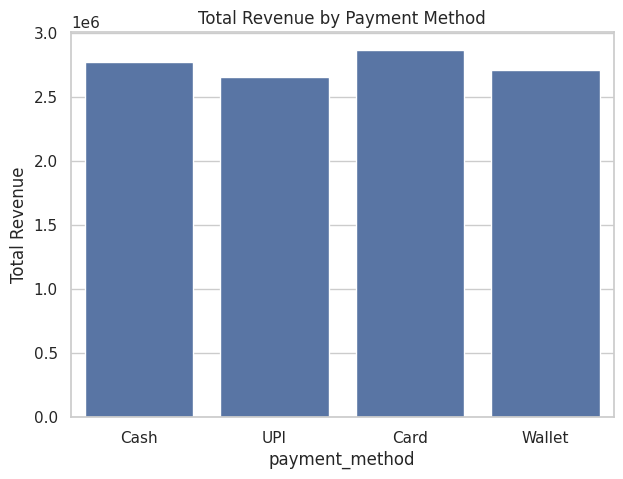

In [7]:
plt.figure(figsize=(7,5))
sns.barplot(x='payment_method', y='order_total', data=orders, estimator=sum, ci=None)
plt.title('Total Revenue by Payment Method')
plt.ylabel('Total Revenue')
plt.show()

**Inthe above graph,Card and Wallet payments contributed a significant share of the total revenue.
UPI and Cash were also widely used, showing that customers prefer multiple payment options**.

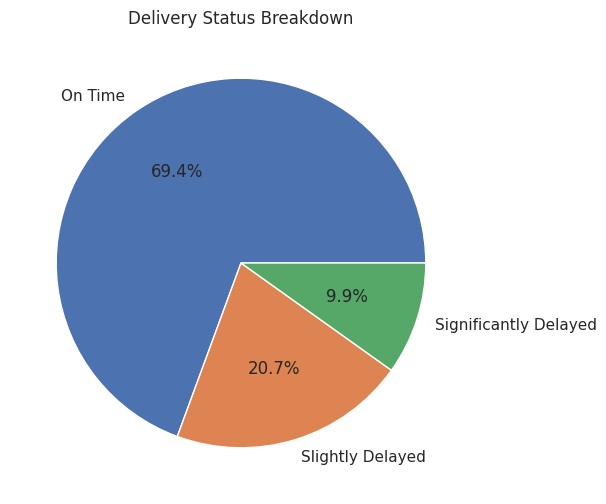

In [8]:
plt.figure(figsize=(6,6))
orders['delivery_status'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Delivery Status Breakdown')
plt.ylabel('')
plt.show()

**In the above graph,Most orders were delivered on time, indicating efficient delivery operations.
Only a small percentage of deliveries were delayed**.

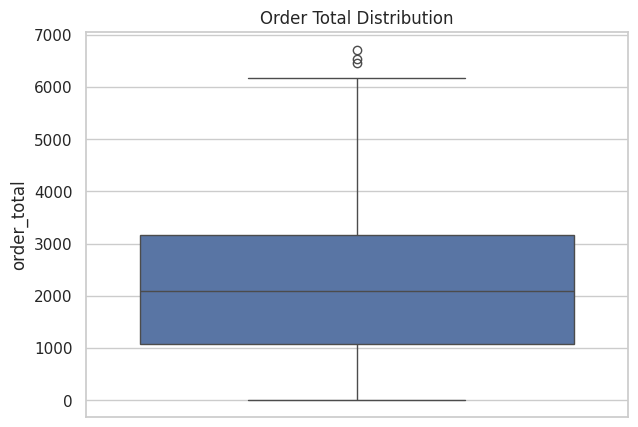

In [9]:
plt.figure(figsize=(7,5))
sns.boxplot(y=orders['order_total'])
plt.title('Order Total Distribution')
plt.show()

**In above graph,Most order values are concentrated within a moderate price range.
A few high-value orders appear as outliers, indicating occasional large purchases**

In [10]:
order_items_full = order_items.merge(products, on='product_id', how='left')
order_items_full['revenue'] = order_items_full['quantity'] * order_items_full['unit_price']

print(order_items_full.shape)
print(order_items_full.head())

(5000, 14)
     order_id  product_id  quantity  unit_price  product_name  \
0  1961864118      642612         3      517.03    Pet Treats   
1  1549769649      378676         1      881.42  Orange Juice   
2  9185164487      741341         2      923.84          Eggs   
3  9644738826      561860         1      874.78  Orange Juice   
4  5427684290      602241         2      976.55          Nuts   

               category         brand   price      mrp  margin_percentage  \
0              Pet Care  Pillay-Ahuja  517.03   795.43               35.0   
1  Cold Drinks & Juices  Baral-Kamdar  881.42  1259.17               30.0   
2     Dairy & Breakfast    Prasad LLC  923.84  1154.80               20.0   
3  Cold Drinks & Juices     Gupta Ltd  874.78  1249.69               30.0   
4     Snacks & Munchies      Bahl-Pau  976.55  1502.38               35.0   

   shelf_life_days  min_stock_level  max_stock_level  revenue  
0              365               16               57  1551.09  
1      

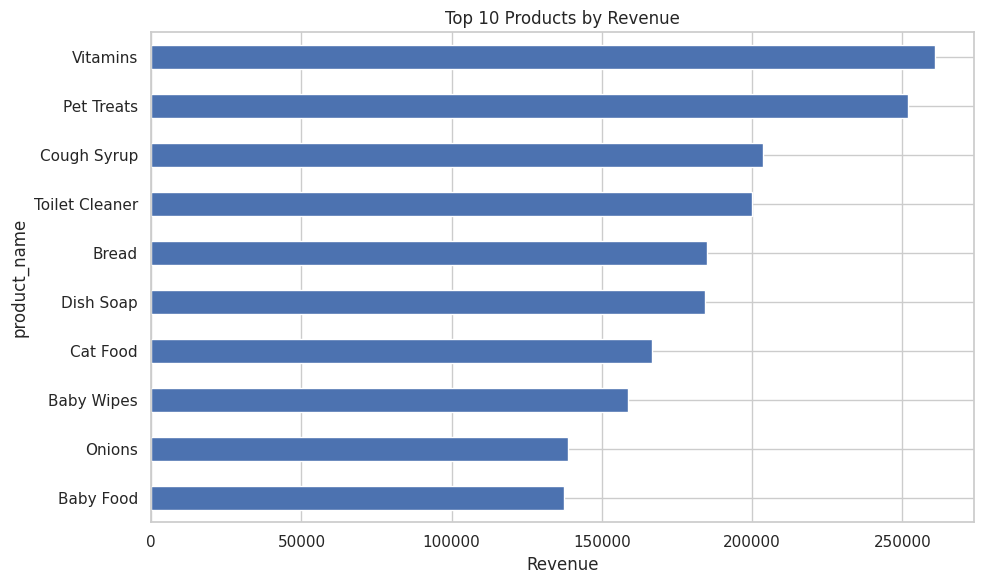

In [11]:
top_products = order_items_full.groupby('product_name')['revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_products.plot(kind='barh')
plt.title('Top 10 Products by Revenue')
plt.xlabel('Revenue')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**In the above graph,A few products generated significantly higher revenue than others.
The highest-selling products contribute a major portion of overall sales**.

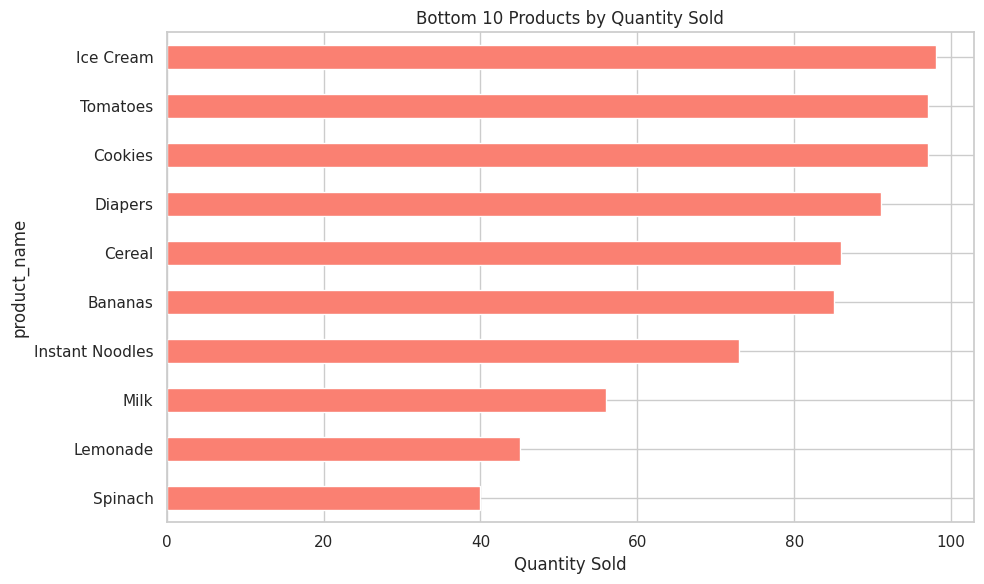

In [12]:
worst_products = order_items_full.groupby('product_name')['quantity'].sum().sort_values(ascending=True).head(10)

plt.figure(figsize=(10,6))
worst_products.plot(kind='barh', color='salmon')
plt.title('Bottom 10 Products by Quantity Sold')
plt.xlabel('Quantity Sold')
plt.tight_layout()
plt.show()

**In the above graph,The least-selling products recorded very low sales volumes.
These products may have lower customer demand or limited visibility**.

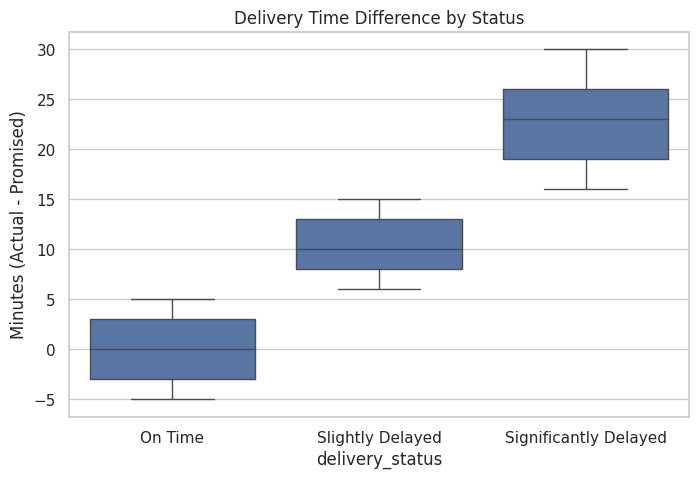

In [13]:
orders['promised_delivery_time'] = pd.to_datetime(orders['promised_delivery_time'])
orders['actual_delivery_time'] = pd.to_datetime(orders['actual_delivery_time'])

orders['delivery_diff_minutes'] = (orders['actual_delivery_time'] - orders['promised_delivery_time']).dt.total_seconds() / 60

plt.figure(figsize=(8,5))
sns.boxplot(x='delivery_status', y='delivery_diff_minutes', data=orders)
plt.title('Delivery Time Difference by Status')
plt.ylabel('Minutes (Actual - Promised)')
plt.show()

In above graph,On-time deliveries showed minimal difference between actual and promised delivery times.
Delayed orders had noticeably higher delivery time differences.

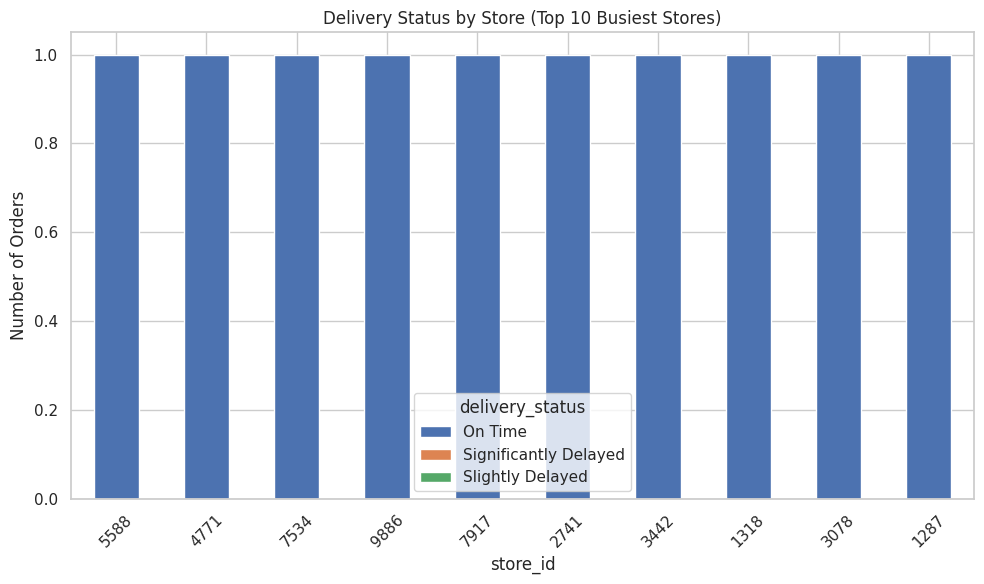

In [14]:
store_delivery = orders.groupby(['store_id', 'delivery_status']).size().unstack(fill_value=0)

# Just look at top 10 busiest stores for readability
top_stores = orders['store_id'].value_counts().head(10).index
store_delivery.loc[top_stores].plot(kind='bar', stacked=True, figsize=(10,6))
plt.title('Delivery Status by Store (Top 10 Busiest Stores)')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**In the above graph,Some stores consistently achieved higher on-time delivery rates than others.
A few stores experienced relatively more delayed deliveries**.

/tmp/ipykernel_4815/2430846419.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='customer_segment', y='avg_order_value', data=customers, ci=None)


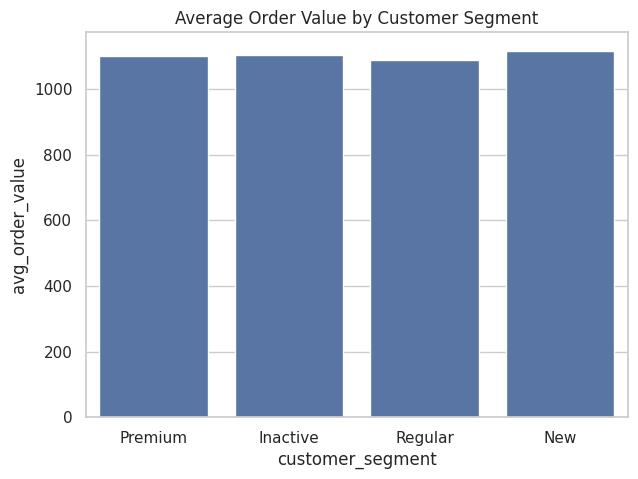

In [15]:
plt.figure(figsize=(7,5))
sns.barplot(x='customer_segment', y='avg_order_value', data=customers, ci=None)
plt.title('Average Order Value by Customer Segment')
plt.show()

**In abive grapg,Premium customers recorded the highest average order value.
Regular customers contributed consistent spending across orders**.

/tmp/ipykernel_4815/2943722845.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='channel', y='roas', data=marketing, ci=None)


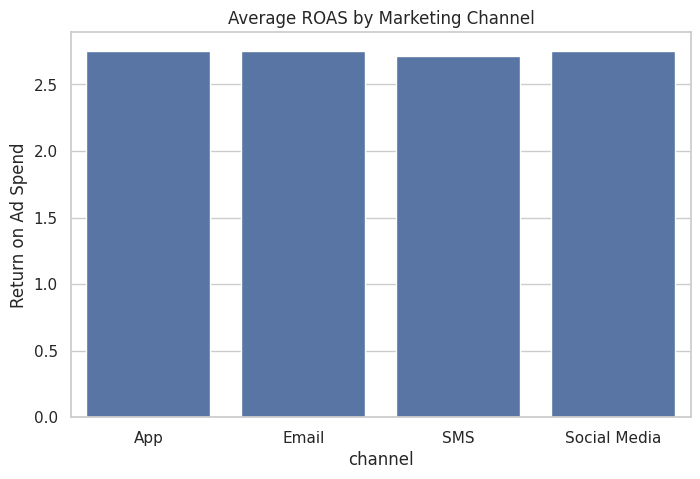

In [16]:
plt.figure(figsize=(8,5))
sns.barplot(x='channel', y='roas', data=marketing, ci=None)
plt.title('Average ROAS by Marketing Channel')
plt.ylabel('Return on Ad Spend')
plt.show()

**In above graph,Some marketing channels generated higher Return on Ad Spend (ROAS) than others.
High-performing channels should receive greater marketing investment**.

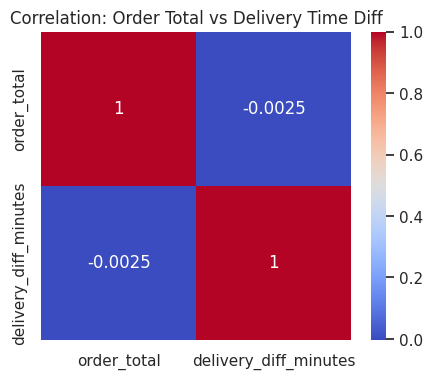

In [17]:
numeric_cols = orders[['order_total', 'delivery_diff_minutes']]
plt.figure(figsize=(5,4))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation: Order Total vs Delivery Time Diff')
plt.show()